# 01. SBA loan data: extracting real-world risk effects

**Purpose.** Metro Deal Desk runs on synthetic loan applications shaped like Metro Finance's business (vehicle and equipment loans via brokers). Pure synthetic data is circular: a model just relearns the formula used to generate it. To avoid that, this notebook measures how default risk actually moves with **industry, business age, loan size, loan term and the economic cycle** in 899,164 real US Small Business Administration (SBA) loans. Those measured effects are exported to `data/calibration/sba_effects.json` and used by the synthetic generator in notebook 02.

**Principle: the SBA data gives the *shape* of risk (relative effects), Australian sources give the *level*.** SBA default rates (around 27% in the window used here) are far above what an Australian secured asset lender would see, so only relative effects (odds ratios) are carried across.

**Source.** Li, M., Mickel, A. and Taylor, S. (2018), "Should This Loan be Approved or Denied?: A Large Dataset with Class Assignment Guidelines", *Journal of Statistics Education*, 26:1, 55-66. CC BY 4.0.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

pd.set_option("display.float_format", "{:,.3f}".format)
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.25, "axes.axisbelow": True})
BAR = "#3b6ea5"   # single series colour
HI = "#c8553d"    # highlight for the reference line

# The raw CSV (179 MB) is too big for GitHub, so it is not committed.
# Put it in data/raw/, or leave it in the parent project folder.
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()  # repo root
CANDIDATES = [ROOT / "data/raw/SBAnational.csv",
              ROOT.parent / "should_this_loan_be_approved/SBAnational.csv"]
RAW = next((p for p in CANDIDATES if p.exists()), None)
assert RAW is not None, "SBAnational.csv not found. Copy it into data/raw/"
OUT_DIR = ROOT / "data/calibration"
OUT_DIR.mkdir(parents=True, exist_ok=True)
print("Reading", RAW.relative_to(ROOT.parent))

Reading should_this_loan_be_approved\SBAnational.csv


## 1. Load and clean

Three cleaning jobs: dates use two-digit years (so `1966` parses as `2066` and needs pulling back a century), money columns are text like `$60,000.00`, and the outcome needs turning into a 0/1 `default` flag.

In [2]:
raw = pd.read_csv(RAW, low_memory=False)
print(f"{len(raw):,} rows, {raw.shape[1]} columns")

def parse_date(s):
    d = pd.to_datetime(s, format="%d-%b-%y", errors="coerce")
    return d.where(d.dt.year <= 2014, d - pd.DateOffset(years=100))  # dataset ends in 2014

def parse_money(s):
    return pd.to_numeric(s.astype(str).str.replace(r"[$,\s]", "", regex=True), errors="coerce")

df = raw.copy()
df["disbursed"] = parse_date(df["DisbursementDate"])
df["amount"] = parse_money(df["DisbursementGross"])
df["sector"] = df["NAICS"].astype(str).str[:2]
df["default"] = (df["MIS_Status"] == "CHGOFF").astype(int)
df[["disbursed", "amount", "Term", "sector", "NewExist", "MIS_Status"]].head()

899,164 rows, 27 columns


,disbursed,amount,Term,sector,NewExist,MIS_Status
0,1999-02-28,"60,000.000",84,45,2.000,P I F
1,1997-05-31,"40,000.000",60,72,2.000,P I F
2,1997-12-31,"287,000.000",180,62,1.000,P I F
3,1997-06-30,"35,000.000",60,0,1.000,P I F
4,1997-05-14,"229,000.000",240,0,1.000,P I F


## 2. Filter to loans that resemble Metro's business

Each filter has a reason, and the row count is logged at every step (the same idea as a rejection log in a production pipeline).

| Filter | Why |
|---|---|
| Outcome known | Need paid-in-full vs charged-off to learn anything |
| Disbursed 2000 to 2010 | Covers a full cycle including the GFC. After 2010, loans still running are missing from the data, so recent years over-represent early defaults (paper, section 3.3) |
| Term under 240 months | 20+ year loans are real estate backed (default 1.6%). Metro does not finance property |
| Industry recorded | NAICS is `0` for about 22% of loans, mostly older ones |
| Not a revolving line of credit | Metro writes fixed-term asset loans, not credit lines |
| Business age recorded | `NewExist` must be 1 (existing) or 2 (new, 2 years or less) |

In [3]:
steps = [
    ("All loans", pd.Series(True, index=df.index)),
    ("Outcome known", df["MIS_Status"].notna()),
    ("Disbursed 2000-2010", df["disbursed"].between("2000-01-01", "2010-12-31")),
    ("Term 1-239 months", df["Term"].between(1, 239)),
    ("Industry recorded", df["sector"] != "0"),
    ("Not a revolving line", ~df["RevLineCr"].isin(["Y", "T"])),
    ("Business age recorded", df["NewExist"].isin([1, 2])),
    ("Amount > 0", df["amount"] > 0),
]
mask = pd.Series(True, index=df.index)
log = []
for name, cond in steps:
    mask &= cond
    log.append({"step": name, "rows_remaining": int(mask.sum()),
                "default_rate": df.loc[mask, "default"].mean()})
filter_log = pd.DataFrame(log)
sba = df[mask].copy()
filter_log

,step,rows_remaining,default_rate
0,All loans,899164,0.175
1,Outcome known,897167,0.176
2,Disbursed 2000-2010,549089,0.244
3,Term 1-239 months,482353,0.273
4,Industry recorded,468147,0.277
5,Not a revolving line,273743,0.271
6,Business age recorded,273379,0.271
7,Amount > 0,273379,0.271


## 3. Map US industries to Metro-style industry groups

NAICS sectors are grouped into the kinds of businesses that buy vehicles and equipment through a broker. Sectors with very few loans (utilities, holding companies, public administration) fold into *Other*.

In [4]:
INDUSTRY_MAP = {
    "11": "Agriculture", "21": "Mining",
    "23": "Construction & trades",
    "31": "Manufacturing", "32": "Manufacturing", "33": "Manufacturing",
    "42": "Wholesale trade",
    "44": "Retail trade", "45": "Retail trade",
    "48": "Transport & logistics", "49": "Transport & logistics",
    "54": "Professional services",
    "56": "Admin & support services",
    "62": "Health care",
    "72": "Hospitality",
    "81": "Other services",
}
sba["industry"] = sba["sector"].map(INDUSTRY_MAP).fillna("Other")
sba["new_business"] = (sba["NewExist"] == 2).astype(int)
sba["term_band"] = pd.cut(sba["Term"], [0, 36, 60, 84, 120, 239],
                          labels=["<=36m", "37-60m", "61-84m", "85-120m", "121-239m"])
sba["size_band"] = pd.cut(sba["amount"], [0, 25e3, 50e3, 100e3, 250e3, np.inf],
                          labels=["<25k", "25-50k", "50-100k", "100-250k", "250k+"])
sba["vintage"] = sba["disbursed"].dt.year
print(f"{len(sba):,} loans, overall default rate {sba['default'].mean():.1%}")

273,379 loans, overall default rate 27.1%


## 4. Default rates one factor at a time

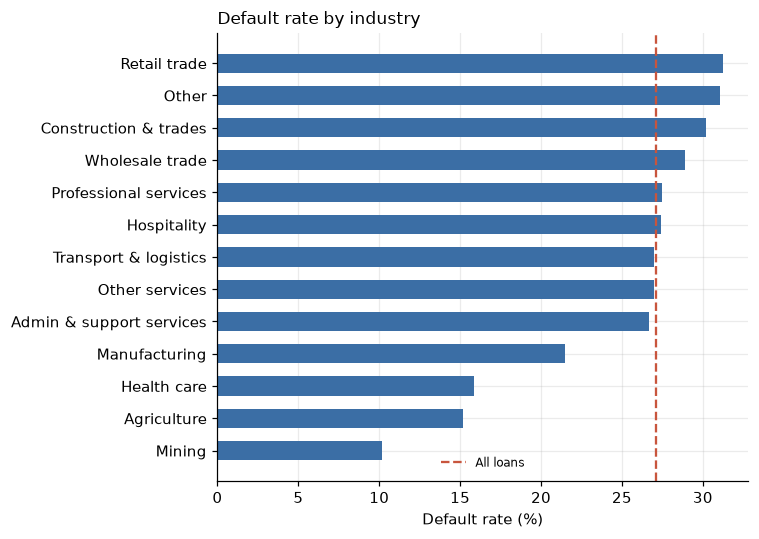

,default_rate,loans
industry,,
Mining,0.101,759
Agriculture,0.152,3212
Health care,0.159,19272
Manufacturing,0.215,24900
Admin & support services,0.267,14125
Other services,0.270,29120
Transport & logistics,0.270,11652
Hospitality,0.274,38337
Professional services,0.275,21656


In [5]:
def rates(col):
    return (sba.groupby(col, observed=True)["default"]
               .agg(default_rate="mean", loans="size"))

def barh(table, title, ax):
    t = table.sort_values("default_rate")
    ax.barh(t.index.astype(str), t["default_rate"] * 100, color=BAR, height=0.6)
    ax.axvline(sba["default"].mean() * 100, color=HI, lw=1.5, ls="--", label="All loans")
    ax.set_xlabel("Default rate (%)"); ax.set_title(title, loc="left", fontsize=11)
    ax.legend(frameon=False, fontsize=8)

ind = rates("industry")
fig, ax = plt.subplots(figsize=(7, 5)); barh(ind, "Default rate by industry", ax); plt.tight_layout(); plt.show()
ind.sort_values("default_rate")

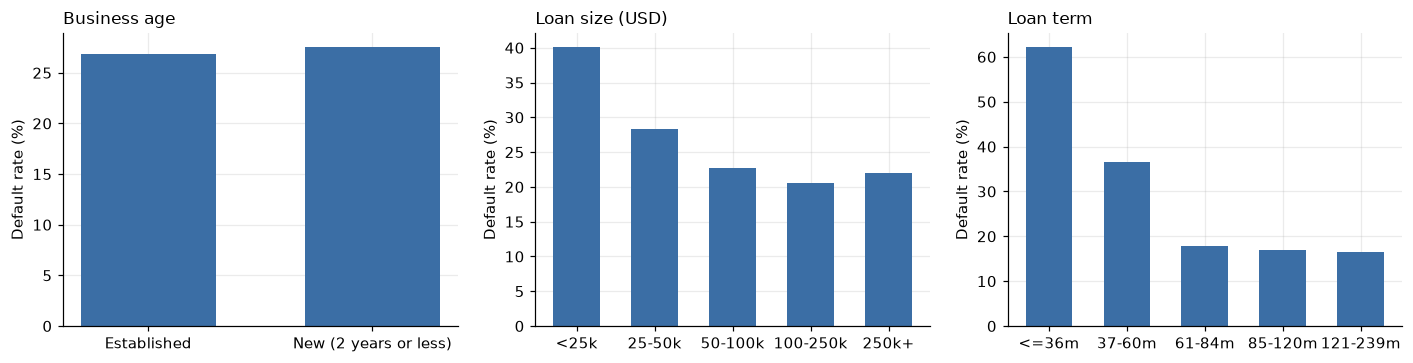

default_rate   loans
new_business 0                0.269  177096
             1                0.275   96283
size_band    <25k             0.401   61508
             25-50k           0.284   52155
             50-100k          0.227   51119
             100-250k         0.206   63925
             250k+            0.220   44672
term_band    <=36m            0.622   31960
             37-60m           0.366   63828
             61-84m           0.178   96453
             85-120m          0.169   61473
             121-239m         0.166   19665

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))
for ax, (col, title) in zip(axes, [("new_business", "Business age"),
                                     ("size_band", "Loan size (USD)"),
                                     ("term_band", "Loan term")]):
    t = rates(col)
    if col == "new_business":
        t.index = ["Established", "New (2 years or less)"]
    ax.bar(t.index.astype(str), t["default_rate"] * 100, color=BAR, width=0.6)
    ax.set_title(title, loc="left", fontsize=11); ax.set_ylabel("Default rate (%)")
plt.tight_layout(); plt.show()
pd.concat({c: rates(c) for c in ["new_business", "size_band", "term_band"]})

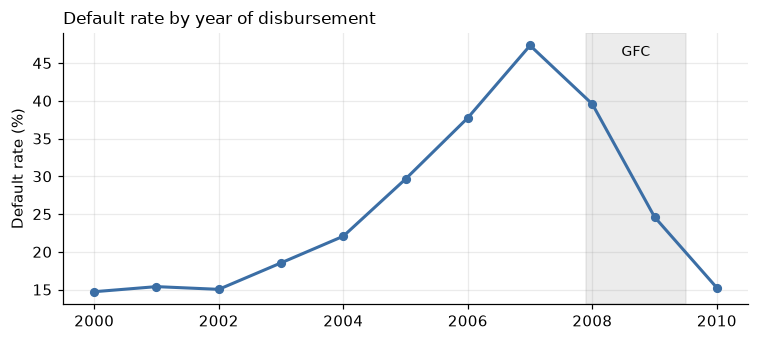

vintage,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010
default_rate,0.147,0.154,0.150,0.185,0.221,0.296,0.377,0.473,0.396,0.246,0.152
loans,"14,572.000","21,918.000","25,689.000","30,103.000","36,020.000","39,329.000","34,688.000","31,980.000","17,172.000","12,241.000","9,667.000"


In [7]:
vin = rates("vintage")
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.plot(vin.index, vin["default_rate"] * 100, color=BAR, lw=2, marker="o", ms=5)
ax.axvspan(2007.9, 2009.5, color="grey", alpha=0.15)
ax.text(2008.7, vin["default_rate"].max() * 100, "GFC", ha="center", va="top", fontsize=9)
ax.set_title("Default rate by year of disbursement", loc="left", fontsize=11); ax.set_ylabel("Default rate (%)")
plt.tight_layout(); plt.show()
vin.T

## 5. Multivariate model: each effect holding the others constant

One-factor tables mix effects together (for example, small loans cluster in riskier industries). A logistic regression separates them. Results are reported as **odds ratios**: 1.5 means 50% higher odds of default than the reference group, 0.7 means 30% lower. Disbursement year is included as a control so the business cycle does not leak into the other effects.

Reference groups: Professional services, established business, loans under $25k, terms of 36 months or less, 2000 vintage.

In [8]:
formula = ("default ~ C(industry, Treatment('Professional services')) + new_business"
           " + C(size_band) + C(term_band) + C(vintage)")
fit = smf.logit(formula, data=sba).fit(disp=0)
ci = np.exp(fit.conf_int()); ci.columns = ["ci_low", "ci_high"]
odds = pd.DataFrame({"odds_ratio": np.exp(fit.params)}).join(ci)
odds.index = (odds.index.str.replace(r"C\(industry, Treatment\('Professional services'\)\)\[T\.", "industry: ", regex=True)
                        .str.replace(r"C\((\w+)\)\[T\.", r"\1: ", regex=True).str.rstrip("]"))
print(f"Pseudo R-squared {fit.prsquared:.3f}, n = {int(fit.nobs):,}")
odds.round(2)

Pseudo R-squared 0.157, n = 273,379


,odds_ratio,ci_low,ci_high
Intercept,1.040,0.970,1.100
industry: Admin & support services,0.950,0.900,1.000
industry: Agriculture,0.610,0.540,0.680
industry: Construction & trades,1.080,1.030,1.130
industry: Health care,0.640,0.600,0.670
industry: Hospitality,1.410,1.350,1.470
industry: Manufacturing,0.890,0.850,0.930
industry: Mining,0.300,0.230,0.380
industry: Other,1.300,1.240,1.360
industry: Other services,1.170,1.120,1.220


## 6. What carries across to Metro, and what does not

| Effect | SBA finding | Carry across? |
|---|---|---|
| **Industry** | Clear spread. Some rankings change once other factors are controlled: transport looks average on its own but lower risk after adjusting for loan size and year, which is why the odds ratios (not the raw rates) are exported | **Yes**, as relative odds. Industry cyclicality is similar in Australia |
| **New business (2 years or less)** | Small effect once other factors are controlled | **Yes, but modest.** The SBA only records a yes/no flag, so the gradient by ABN age will be shaped with ABS business survival data |
| **Loan size** | Loans under $25k default far more; the effect flattens above $50k | **Yes**, as relative odds |
| **Economic cycle** | 2007 vintage has several times the odds of 2000 | **Yes, as a stress scenario** in the dashboard, not a baseline feature |
| **Loan term** | Short terms (36 months or less) default *most* | **No.** SBA short-term loans are mostly working capital and express programs, a different product. For secured vehicle loans, longer terms are riskier because the balance falls more slowly than the asset's value. The generator uses that economic reasoning instead |
| **Base default rate** | About 27% over the life of the loan | **No.** Far above an Australian secured asset lender. The level comes from Australian sources |
| **LowDoc, urban/rural** | Coding artefacts and programme differences | **No** |

**Known limitations** (to repeat in the README's data provenance section):
1. *Selection bias*: the data only contains loans that were approved, so it says nothing about applicants who were declined.
2. *Time window*: loans after 2010 are excluded to avoid over-counting early defaults, so the data reflects the 2000s.
3. *Different market*: US government-guaranteed small business loans, not Australian secured asset finance. Only relative effects are used.

## 7. Export calibration file

In [9]:
def ors(prefix):
    sub = odds[odds.index.str.startswith(prefix)]
    return {k.replace(prefix, ""): round(float(v), 3) for k, v in sub["odds_ratio"].items()}

industry_or = {"Professional services": 1.0, **ors("industry: ")}
calibration = {
    "source": "US SBA National dataset (Li, Mickel and Taylor 2018), CC BY 4.0",
    "sample": {"loans": int(len(sba)), "window": "disbursed 2000-2010",
               "filters": filter_log["step"].tolist()[1:],
               "sba_default_rate": round(float(sba["default"].mean()), 4)},
    "use": "Relative effects only. Base rates come from Australian sources.",
    "industry": {k: {"odds_ratio": industry_or.get(k, 1.0),
                     "sba_default_rate": round(float(ind.loc[k, "default_rate"]), 4),
                     "sba_loans": int(ind.loc[k, "loans"])} for k in ind.index},
    "new_business_odds_ratio": round(float(np.exp(fit.params["new_business"])), 3),
    "loan_size_odds_ratio_usd": {"<25k": 1.0, **ors("size_band: ")},
    "cycle_stress_odds_ratio_by_vintage": {"2000": 1.0, **ors("vintage: ")},
    "not_carried": {
        "term": "SBA short-term loans are a different product; generator uses asset-finance logic instead",
        "base_rate": "SBA level far above Australian secured asset finance",
        "lowdoc_urban": "coding artefacts and programme differences"},
}
path = OUT_DIR / "sba_effects.json"
path.write_text(json.dumps(calibration, indent=2))
print("Wrote", path.relative_to(ROOT))
print(json.dumps({k: calibration[k] for k in ["new_business_odds_ratio", "loan_size_odds_ratio_usd"]}, indent=2))

Wrote data\calibration\sba_effects.json
{
  "new_business_odds_ratio": 1.081,
  "loan_size_odds_ratio_usd": {
    "<25k": 1.0,
    "25-50k": 0.625,
    "50-100k": 0.558,
    "100-250k": 0.668,
    "250k+": 0.864
  }
}
